# Financial Returns Prediction with Topic-Level EPI (LSTM · MLX)

This notebook copies `514_financial_lstm_mlx.ipynb` but replaces aggregate EPI features with the full set of topic-level signals from `data/epi_data.json`. We build topic lags/rolling means, apply permutation-based feature selection to keep the most predictive topics, and evaluate their impact on BTC/Gold/SPX returns using MLX LSTMs.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlx.core as mx
import mlx.nn as nn
from mlx.optimizers import AdamW

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (12, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
EPI_FILE = DATA_DIR + "epi_data.json"

# Analysis window (same as XGBoost notebook)
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"

# Topic configuration (focus set supplied by user for reporting)
TOPIC_FOCUS = [
    "epi_Environmental and Infrastructure",
    "epi_Labor and Workforce",
    "epi_Health and Social Welfare",
    "epi_Legal and Regulatory Framework",
    "epi_Education and Knowledge",
    "epi_Psychological and Emotional Aspects",
    "epi_Leadership and Governance",
    "epi_Economic and Financial Matters",
    "epi_Disaster and Resilience",
]
TOPIC_MAX_LAG = 3           # lag depth for topic features
FEATURE_SELECTION_THRESHOLD_PCT = 0.5  # keep features with >0.5% baseline RMSE contribution
MIN_SELECTED_FEATURES = 12   # ensure a reasonable set survives selection

np.random.seed(42)
mx.random.seed(42)



## 1. Load and Prepare Data

Load financial data, merge topic-level EPI signals, and build returns/control variables.



In [2]:
# --- Load raw financial data ---
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

if "Date_" not in df_raw.columns:
    raise KeyError("Expected a 'Date_' column in the market data file.")

# Parse dates and sort
df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
df_raw = df_raw.sort_values("Date_").set_index("Date_")

# Rename columns to simpler names (matches XGBoost notebook)
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Close_GC=F": "close_gold",
    "Close_CL=F": "close_oil",
    "Close_^GSPC": "close_spx",
    "Close_CNY=X": "close_usdcny",
    "Close_EUR=X": "close_eurusd",
    "Close_^TNX": "close_ust10y",
    "Volume_BTC-USD": "vol_btc",
    "Volume_GC=F": "vol_gold",
    "Volume_^GSPC": "vol_spx",
}

df = df_raw.rename(columns=rename_map)

# Create business-day index and forward-fill prices
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)
price_cols = [c for c in df.columns if c.startswith("close_")]
df[price_cols] = df[price_cols].ffill()

# Construct returns and control variables
def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)
returns["r_btc"] = log_return(df["close_btc"])
returns["r_gold"] = log_return(df["close_gold"])
returns["r_spx"] = log_return(df["close_spx"])

returns["dln_eurusd"] = log_return(df["close_eurusd"])
returns["dln_usdcny"] = log_return(df["close_usdcny"])
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

returns = returns.dropna().loc[START_DATE:END_DATE]

# Load EPI data (topic-level)
df_epi = pd.read_json(EPI_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

# Identify topic-level columns (exclude aggregate epi/epi_weighted and placeholder column)
topic_cols_all = sorted([
    col for col in df_epi.columns
    if col.startswith('epi_') and col not in ['epi', 'epi_weighted', 'epi_']
])

focus_topic_cols = [col for col in TOPIC_FOCUS if col in topic_cols_all]
missing_focus = sorted(set(TOPIC_FOCUS) - set(focus_topic_cols))
if missing_focus:
    print(f"Missing requested topics (not found in data): {missing_focus}")

# Merge base EPI aggregates + topic columns
epi_cols = ["epi", "epi_weighted"] + topic_cols_all
returns = returns.join(df_epi[epi_cols], how='left')
returns[epi_cols] = returns[epi_cols].fillna(0)

print(f"Data window: {returns.index.min().date()} to {returns.index.max().date()}")
print(f"Topic columns found: {len(topic_cols_all)}")
print(f"Focus topics available: {focus_topic_cols}")



Data window: 2025-01-01 to 2025-05-30
Topic columns found: 18
Focus topics available: ['epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience']


## 2. Feature Engineering

**Variables of Interest:** Topic-level EPI signals (contemporaneous, lags, rolling means)  
**Control Variables:** FX rates, oil, interest rates, lagged returns, volatility



In [3]:
# Configuration
MAX_RETURN_LAG = 3  # Lagged returns for controls

data = returns.copy()

# =============================================================================
# CONTROL VARIABLES (baseline features)
# =============================================================================

# 1. Lagged asset returns
for asset in ["r_btc", "r_gold", "r_spx"]:
    for lag in range(1, MAX_RETURN_LAG + 1):
        data[f"{asset}_l{lag}"] = data[asset].shift(lag)

# 2. Rolling volatility
for asset in ["r_btc", "r_gold", "r_spx"]:
    data[f"{asset}_vol5"] = data[asset].rolling(5).std()

# =============================================================================
# VARIABLES OF INTEREST: Topic-level EPI signals with lags + rolling mean
# =============================================================================

topic_feature_cols = []
for topic in topic_cols_all:
    topic_feature_cols.append(topic)  # contemporaneous
    for lag in range(1, TOPIC_MAX_LAG + 1):
        lag_col = f"{topic}_l{lag}"
        data[lag_col] = data[topic].shift(lag)
        topic_feature_cols.append(lag_col)
    roll_col = f"{topic}_ma5"
    data[roll_col] = data[topic].rolling(5).mean()
    topic_feature_cols.append(roll_col)

data = data.dropna()

# Print summary
print(f"Data shape: {data.shape}")
print(f"{'='*60}")
print("VARIABLE ORGANIZATION")
print(f"{'='*60}")
print(f"CONTROL VARIABLES:")
print(f"  - Macro controls: {['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']}")
print(f"  - Lagged returns: {[f'r_*_l{i}' for i in range(1, MAX_RETURN_LAG+1)]}")
print(f"  - Volatility: r_*_vol5")
print(f"VARIABLES OF INTEREST (TOPIC EPI):")
print(f"  - Topics: {len(topic_cols_all)}")
print(f"  - Features per topic: contemporaneous + lags 1-{TOPIC_MAX_LAG} + 5d mean")
print(f"  - Total topic-derived features: {len(topic_feature_cols)}")



Data shape: (104, 111)
VARIABLE ORGANIZATION
CONTROL VARIABLES:
  - Macro controls: ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']
  - Lagged returns: ['r_*_l1', 'r_*_l2', 'r_*_l3']
  - Volatility: r_*_vol5
VARIABLES OF INTEREST (TOPIC EPI):
  - Topics: 18
  - Features per topic: contemporaneous + lags 1-3 + 5d mean
  - Total topic-derived features: 90


## 3. Model Specifications

**Research Design:**
- **Baseline**: Control variables only (no topics)
- **Topics (all)**: Baseline + all topic features (with lags/rolling)
- **Topics (focus)**: Baseline + only the requested focus topics (lags/rolling)



In [4]:
# =============================================================================
# CONTROL VARIABLES (used in all models)
# =============================================================================
macro_controls = ["dln_eurusd", "dln_usdcny", "dln_oil", "dy10"]

def get_control_features(asset: str) -> list:
    """Get baseline control features (no EPI)."""
    # Lagged own returns
    lag_cols = [f"{asset}_l{lag}" for lag in range(1, MAX_RETURN_LAG + 1)]
    # Cross-asset lagged returns
    other_assets = [a for a in ["r_btc", "r_gold", "r_spx"] if a != asset]
    cross_cols = [f"{a}_l1" for a in other_assets]
    # Volatility
    vol_cols = [f"{asset}_vol5"]
    
    return lag_cols + cross_cols + macro_controls + vol_cols


def get_feature_cols(asset: str, model_type: str = "baseline") -> list:
    """
    Get all features for a model specification.
    
    Model types:
        - baseline: controls only (no topics)
        - topics_all: all topic features
        - topics_focus: only focus topics (subset of topics_all)
    """
    controls = get_control_features(asset)
    
    if model_type == "baseline":
        return controls
    
    if model_type == "topics_all":
        return controls + topic_feature_cols
    
    if model_type == "topics_focus":
        focus_features = [f for f in topic_feature_cols if any(f.startswith(t) for t in focus_topic_cols)]
        if not focus_features:  # fallback if focus list missing in data
            focus_features = topic_feature_cols
        return controls + focus_features
    
    raise ValueError(f"Unknown model type: {model_type}")


# =============================================================================
# Define model specifications to test
# =============================================================================

MODEL_SPECS = {
    "baseline": "Controls only (no topics)",
    "topics_all": "All topic features (contemp + lags + MA)",
    "topics_focus": "Focus topic subset (contemp + lags + MA)",
}

print("=" * 70)
print("MODEL SPECIFICATIONS")
print("=" * 70)
for model, desc in MODEL_SPECS.items():
    n_added = len(get_feature_cols("r_btc", model)) - len(get_control_features("r_btc"))
    print(f"  {model:25s} | {desc:45s} | +{n_added} topic vars")



MODEL SPECIFICATIONS
  baseline                  | Controls only (no topics)                     | +0 topic vars
  topics_all                | All topic features (contemp + lags + MA)      | +90 topic vars
  topics_focus              | Focus topic subset (contemp + lags + MA)      | +45 topic vars


## 4. MLX LSTM helpers (sequence builder, model, training loop)

In [5]:
from typing import Dict, List, Tuple, Optional
import copy
import mlx.utils


def make_sequences(features: np.ndarray, targets: np.ndarray, seq_len: int, index: pd.Index):
    X_seq, y_seq, seq_dates = [], [], []
    for i in range(seq_len, len(features)):
        X_seq.append(features[i - seq_len : i])
        y_seq.append(targets[i])
        seq_dates.append(index[i])
    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_seq, dtype=np.float32),
        pd.Index(seq_dates),
    )


def compute_metrics(actuals: np.ndarray, preds: np.ndarray) -> Dict[str, float]:
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    # Handle zero returns for directional accuracy
    mask = actuals != 0
    if mask.sum() > 0:
        dir_acc = np.mean(np.sign(actuals[mask]) == np.sign(preds[mask])) * 100
    else:
        dir_acc = 50.0
    return {"rmse": rmse, "mae": mae, "dir_acc": dir_acc}


def copy_weights(weights):
    """Deep copy model weights (nested dict of arrays)."""
    return mlx.utils.tree_map(lambda x: mx.array(x), weights)


class TemporalAttention(nn.Module):
    """Simple attention over timesteps to focus on important periods."""
    
    def __init__(self, hidden_size: int):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)
    
    def __call__(self, x):
        # x: (batch, seq_len, hidden)
        scores = self.attention(x)  # (batch, seq_len, 1)
        weights = mx.softmax(scores, axis=1)
        # Weighted sum over timesteps
        context = mx.sum(x * weights, axis=1)  # (batch, hidden)
        return context, weights


class ImprovedLSTMRegressor(nn.Module):
    """Enhanced LSTM with attention, layer norm, and residual connections."""

    def __init__(
        self, 
        input_size: int, 
        hidden_size: int = 64, 
        num_layers: int = 2, 
        dropout: float = 0.2,
        use_attention: bool = True,
        use_layer_norm: bool = True,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout_rate = dropout
        self.use_attention = use_attention
        self.use_layer_norm = use_layer_norm
        
        # Input projection for residual
        self.input_proj = nn.Linear(input_size, hidden_size) if input_size != hidden_size else None
        
        # Stack LSTM layers
        self.lstm_layers = []
        self.layer_norms = [] if use_layer_norm else None
        
        for i in range(num_layers):
            layer_input_size = input_size if i == 0 else hidden_size
            self.lstm_layers.append(nn.LSTM(layer_input_size, hidden_size))
            if use_layer_norm:
                self.layer_norms.append(nn.LayerNorm(hidden_size))
        
        # Dropout
        self.dropout = nn.Dropout(p=dropout) if dropout > 0 else None
        
        # Attention mechanism
        self.attention = TemporalAttention(hidden_size) if use_attention else None
        
        # Output head with extra hidden layer
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, 1)

    def __call__(self, x):
        # x: (batch, seq_len, features)
        batch_size, seq_len, _ = x.shape
        
        # MLX LSTM expects (seq_len, batch, features)
        out = mx.swapaxes(x, 0, 1)
        
        for i, lstm in enumerate(self.lstm_layers):
            lstm_out, _ = lstm(out)
            
            # Layer normalization
            if self.use_layer_norm:
                # Swap to (batch, seq, hidden) for layer norm
                lstm_out_t = mx.swapaxes(lstm_out, 0, 1)
                lstm_out_t = self.layer_norms[i](lstm_out_t)
                lstm_out = mx.swapaxes(lstm_out_t, 0, 1)
            
            # Residual connection (after first layer)
            if i > 0:
                lstm_out = lstm_out + out
            
            # Dropout between layers
            if self.dropout is not None and i < self.num_layers - 1:
                lstm_out = self.dropout(lstm_out)
            
            out = lstm_out
        
        # Swap back: (seq, batch, hidden) -> (batch, seq, hidden)
        out = mx.swapaxes(out, 0, 1)
        
        # Attention or last timestep
        if self.use_attention:
            context, _ = self.attention(out)
        else:
            context = out[:, -1, :]
        
        # Two-layer head with GELU activation
        h = nn.gelu(self.fc1(context))
        if self.dropout is not None:
            h = self.dropout(h)
        return self.fc2(h).squeeze(-1)


def get_lr_schedule(epoch: int, total_epochs: int, base_lr: float, warmup_epochs: int = 5) -> float:
    """Cosine annealing with linear warmup."""
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return base_lr * 0.5 * (1 + np.cos(np.pi * progress))


def clip_gradients(grads, max_norm: float = 1.0):
    """Clip gradients by global norm."""
    def compute_norm(g):
        if isinstance(g, mx.array):
            return float(mx.sum(g * g))
        return 0.0
    
    total_norm_sq = mlx.utils.tree_reduce(lambda acc, g: acc + compute_norm(g), grads, 0.0)
    total_norm = np.sqrt(total_norm_sq)
    
    if total_norm > max_norm:
        scale = max_norm / (total_norm + 1e-6)
        grads = mlx.utils.tree_map(lambda g: g * scale if isinstance(g, mx.array) else g, grads)
    
    return grads


def train_lstm_model(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    seq_len: int = 15,  # Reduced for small dataset
    hidden_size: int = 32,  # Smaller to reduce overfitting
    num_layers: int = 2,
    dropout: float = 0.2,
    learning_rate: float = 1e-3,
    epochs: int = 100,
    batch_size: int = 16,  # Smaller batches
    patience: int = 15,  # More patience
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
    use_attention: bool = True,
    use_layer_norm: bool = True,
    grad_clip: float = 1.0,
    verbose: bool = True,
):
    df_fit = df.dropna(subset=[asset] + feature_cols)
    if len(df_fit) <= seq_len + 10:
        return {"error": "Insufficient data after lagging for LSTM."}

    # Time-based split
    train_end = int(len(df_fit) * train_ratio)
    val_end = int(len(df_fit) * (train_ratio + val_ratio))

    features = df_fit[feature_cols].values.astype(np.float32)
    target = df_fit[asset].values.astype(np.float32)

    # Robust scaling (less sensitive to outliers)
    scaler = StandardScaler()
    scaler.fit(features[:train_end])
    features_scaled = scaler.transform(features)

    X_seq, y_seq, seq_dates = make_sequences(features_scaled, target, seq_len, df_fit.index)

    train_cut = max(train_end - seq_len, 1)
    val_cut = max(val_end - seq_len, train_cut + 1)

    X_train, y_train = X_seq[:train_cut], y_seq[:train_cut]
    X_val, y_val = X_seq[train_cut:val_cut], y_seq[train_cut:val_cut]
    X_test, y_test = X_seq[val_cut:], y_seq[val_cut:]
    date_test = seq_dates[val_cut:]

    if len(X_test) == 0:
        return {"error": "Test window empty; reduce seq_len or adjust split."}

    # Data augmentation: add small noise to training data
    X_train_aug = X_train + np.random.normal(0, 0.01, X_train.shape).astype(np.float32)
    X_train_combined = np.concatenate([X_train, X_train_aug], axis=0)
    y_train_combined = np.concatenate([y_train, y_train], axis=0)

    model = ImprovedLSTMRegressor(
        X_train.shape[-1], 
        hidden_size=hidden_size, 
        num_layers=num_layers, 
        dropout=dropout,
        use_attention=use_attention,
        use_layer_norm=use_layer_norm,
    )
    
    # Use AdamW with weight decay
    optimizer = AdamW(learning_rate=learning_rate, weight_decay=1e-3)

    def loss_fn(model, xb, yb):
        preds = model(xb)
        mse = mx.mean((preds - yb) ** 2)
        return mse

    loss_and_grad = nn.value_and_grad(model, loss_fn)

    best_weights = None
    best_val = np.inf
    wait = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # Update learning rate
        current_lr = get_lr_schedule(epoch, epochs, learning_rate)
        optimizer.learning_rate = current_lr
        
        # Training with shuffled augmented data
        perm = np.random.permutation(len(X_train_combined))
        epoch_loss = 0.0
        n_batches = 0
        
        for start in range(0, len(perm), batch_size):
            idx = perm[start : start + batch_size]
            xb = mx.array(X_train_combined[idx])
            yb = mx.array(y_train_combined[idx])
            
            loss, grads = loss_and_grad(model, xb, yb)
            
            # Gradient clipping
            if grad_clip > 0:
                grads = clip_gradients(grads, grad_clip)
            
            optimizer.update(model, grads)
            mx.eval(model.parameters(), optimizer.state)
            
            epoch_loss += float(loss)
            n_batches += 1

        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)

        # Validation
        if len(X_val) > 0:
            val_pred = model(mx.array(X_val))
            val_loss = float(mx.mean((val_pred - mx.array(y_val)) ** 2))
        else:
            val_loss = avg_train_loss
        val_losses.append(val_loss)

        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:03d} | LR {current_lr:.6f} | Train {avg_train_loss:.6f} | Val {val_loss:.6f}")

        # Early stopping with patience
        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_weights = copy_weights(model.parameters())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break

    if best_weights is not None:
        model.update(best_weights)

    # Evaluation
    test_pred = model(mx.array(X_test))
    test_pred_np = np.asarray(test_pred).reshape(-1)
    metrics = compute_metrics(y_test, test_pred_np)

    preds_series = pd.Series(test_pred_np, index=date_test)
    actual_series = pd.Series(y_test, index=date_test)

    return {
        **metrics,
        "predictions": preds_series,
        "actuals": actual_series,
        "val_loss": best_val,
        "feature_cols": feature_cols,
        "seq_len": seq_len,
        "scaler": scaler,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test": len(X_test),
    }

## 4. MLX LSTM helpers (sequence builder, model, training loop)



In [6]:
def walk_forward_validation(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    n_splits: int = 5,
    min_train_size: int = 40,
    test_size: int = 10,
    seq_len: int = 10,
    hidden_size: int = 32,
    num_layers: int = 2,
    dropout: float = 0.3,
    learning_rate: float = 5e-4,
    weight_decay: float = 1e-3,  # Added weight_decay parameter
    epochs: int = 100,
    batch_size: int = 8,
    patience: int = 15,
    verbose: bool = False,
) -> Dict:
    """
    Walk-forward (expanding window) cross-validation for time series.
    
    Each fold:
    - Train on all data up to split point
    - Test on next `test_size` observations
    - Move forward and repeat
    
    Returns aggregated metrics across all folds.
    """
    df_fit = df.dropna(subset=[asset] + feature_cols)
    n_samples = len(df_fit)
    
    if n_samples < min_train_size + test_size + seq_len:
        return {"error": "Insufficient data for walk-forward validation"}
    
    # Calculate split points
    available_for_test = n_samples - min_train_size - seq_len
    actual_splits = min(n_splits, available_for_test // test_size)
    
    if actual_splits < 2:
        return {"error": f"Can only do {actual_splits} splits, need at least 2"}
    
    all_preds = []
    all_actuals = []
    all_dates = []
    fold_results = []
    
    for fold in range(actual_splits):
        # Expanding window: train size grows with each fold
        train_end_idx = min_train_size + fold * test_size
        test_start_idx = train_end_idx
        test_end_idx = min(test_start_idx + test_size, n_samples)
        
        if test_end_idx <= test_start_idx:
            break
            
        # Extract fold data
        features = df_fit[feature_cols].values.astype(np.float32)
        target = df_fit[asset].values.astype(np.float32)
        
        # Fit scaler on training data only
        scaler = StandardScaler()
        scaler.fit(features[:train_end_idx])
        features_scaled = scaler.transform(features)
        
        # Create sequences
        X_seq, y_seq, seq_dates = make_sequences(features_scaled, target, seq_len, df_fit.index)
        
        # Adjust indices for sequences
        train_cut = max(train_end_idx - seq_len, 1)
        test_start = train_cut
        test_end = min(test_end_idx - seq_len, len(X_seq))
        
        if test_end <= test_start:
            continue
            
        X_train, y_train = X_seq[:train_cut], y_seq[:train_cut]
        X_test, y_test = X_seq[test_start:test_end], y_seq[test_start:test_end]
        date_test = seq_dates[test_start:test_end]
        
        if len(X_train) < 10 or len(X_test) == 0:
            continue
        
        # Train model for this fold
        model = ImprovedLSTMRegressor(
            X_train.shape[-1],
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            use_attention=False,      # Disable attention (simpler model)
            use_layer_norm=True,
        )
        optimizer = AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
        
        def loss_fn(model, xb, yb):
            return mx.mean((model(xb) - yb) ** 2)
        
        loss_and_grad = nn.value_and_grad(model, loss_fn)
        
        best_weights = None
        best_loss = np.inf
        wait = 0
        
        # Use last 20% of training as validation
        val_size = max(int(len(X_train) * 0.2), 1)
        X_tr, y_tr = X_train[:-val_size], y_train[:-val_size]
        X_vl, y_vl = X_train[-val_size:], y_train[-val_size:]
        
        for epoch in range(epochs):
            current_lr = get_lr_schedule(epoch, epochs, learning_rate)
            optimizer.learning_rate = current_lr
            
            perm = np.random.permutation(len(X_tr))
            for start in range(0, len(perm), batch_size):
                idx = perm[start:start + batch_size]
                xb, yb = mx.array(X_tr[idx]), mx.array(y_tr[idx])
                loss, grads = loss_and_grad(model, xb, yb)
                grads = clip_gradients(grads, 1.0)
                optimizer.update(model, grads)
                mx.eval(model.parameters(), optimizer.state)
            
            # Validation
            val_pred = model(mx.array(X_vl))
            val_loss = float(mx.mean((val_pred - mx.array(y_vl)) ** 2))
            
            if val_loss < best_loss - 1e-7:
                best_loss = val_loss
                best_weights = copy_weights(model.parameters())
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break
        
        if best_weights is not None:
            model.update(best_weights)
        
        # Predict on test fold
        test_pred = model(mx.array(X_test))
        test_pred_np = np.asarray(test_pred).reshape(-1)
        
        # Also compute train RMSE for overfitting diagnostic
        train_pred = model(mx.array(X_train))
        train_pred_np = np.asarray(train_pred).reshape(-1)
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred_np))
        
        all_preds.extend(test_pred_np)
        all_actuals.extend(y_test)
        all_dates.extend(date_test)
        
        fold_metric = compute_metrics(y_test, test_pred_np)
        # Add train/test RMSE for overfitting diagnostic
        fold_metric['train_rmse'] = train_rmse
        fold_metric['test_rmse'] = fold_metric['rmse']
        fold_results.append(fold_metric)
        
        if verbose:
            print(f"Fold {fold+1}/{actual_splits}: Train RMSE={train_rmse:.5f}, "
                  f"Test RMSE={fold_metric['rmse']:.5f}, "
                  f"DirAcc={fold_metric['dir_acc']:.1f}%, n_test={len(y_test)}")
    
    if not all_preds:
        return {"error": "No successful folds"}
    
    # Aggregate metrics
    all_preds = np.array(all_preds)
    all_actuals = np.array(all_actuals)
    overall_metrics = compute_metrics(all_actuals, all_preds)
    
    # Calculate std across folds
    rmse_std = np.std([f['rmse'] for f in fold_results])
    dir_acc_std = np.std([f['dir_acc'] for f in fold_results])
    
    return {
        **overall_metrics,
        "rmse_std": rmse_std,
        "dir_acc_std": dir_acc_std,
        "n_folds": len(fold_results),
        "fold_results": fold_results,  # Changed from fold_metrics to fold_results
        "predictions": pd.Series(all_preds, index=pd.Index(all_dates)),
        "actuals": pd.Series(all_actuals, index=pd.Index(all_dates)),
    }


def permutation_feature_importance(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    n_repeats: int = 5,
    seq_len: int = 10,
    hidden_size: int = 32,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Compute permutation feature importance.
    
    For each feature:
    1. Train model with all features
    2. Shuffle that feature in test set
    3. Measure increase in error (importance)
    
    Higher importance = feature matters more.
    """
    df_fit = df.dropna(subset=[asset] + feature_cols)
    
    # Simple train/test split for importance calculation
    train_end = int(len(df_fit) * 0.8)
    
    features = df_fit[feature_cols].values.astype(np.float32)
    target = df_fit[asset].values.astype(np.float32)
    
    scaler = StandardScaler()
    scaler.fit(features[:train_end])
    features_scaled = scaler.transform(features)
    
    X_seq, y_seq, _ = make_sequences(features_scaled, target, seq_len, df_fit.index)
    
    train_cut = max(train_end - seq_len, 1)
    X_train, y_train = X_seq[:train_cut], y_seq[:train_cut]
    X_test, y_test = X_seq[train_cut:], y_seq[train_cut:]
    
    if len(X_test) == 0:
        return pd.DataFrame({"feature": feature_cols, "importance": [0] * len(feature_cols)})
    
    # Train baseline model
    model = ImprovedLSTMRegressor(
        X_train.shape[-1],
        hidden_size=hidden_size,
        num_layers=2,
        dropout=0.2,
        use_attention=True,
        use_layer_norm=True,
    )
    optimizer = AdamW(learning_rate=5e-4, weight_decay=1e-3)
    
    def loss_fn(model, xb, yb):
        return mx.mean((model(xb) - yb) ** 2)
    
    loss_and_grad = nn.value_and_grad(model, loss_fn)
    
    # Quick training
    for epoch in range(50):
        perm = np.random.permutation(len(X_train))
        for start in range(0, len(perm), 16):
            idx = perm[start:start + 16]
            xb, yb = mx.array(X_train[idx]), mx.array(y_train[idx])
            loss, grads = loss_and_grad(model, xb, yb)
            optimizer.update(model, grads)
            mx.eval(model.parameters(), optimizer.state)
    
    # Baseline score
    baseline_pred = np.asarray(model(mx.array(X_test))).reshape(-1)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    
    if verbose:
        print(f"Baseline RMSE: {baseline_rmse:.5f}")
    
    # Permutation importance for each feature
    importances = []
    
    for feat_idx, feat_name in enumerate(feature_cols):
        feat_scores = []
        
        for _ in range(n_repeats):
            # Shuffle feature across all timesteps in sequence
            X_test_perm = X_test.copy()
            # Shuffle the feature values across samples
            perm_vals = X_test_perm[:, :, feat_idx].flatten()
            np.random.shuffle(perm_vals)
            X_test_perm[:, :, feat_idx] = perm_vals.reshape(X_test_perm.shape[0], X_test_perm.shape[1])
            
            perm_pred = np.asarray(model(mx.array(X_test_perm))).reshape(-1)
            perm_rmse = np.sqrt(mean_squared_error(y_test, perm_pred))
            
            # Importance = increase in error when feature is shuffled
            feat_scores.append(perm_rmse - baseline_rmse)
        
        importance = np.mean(feat_scores)
        importance_std = np.std(feat_scores)
        importances.append({
            "feature": feat_name,
            "importance": importance,
            "importance_std": importance_std,
            "importance_pct": (importance / baseline_rmse) * 100 if baseline_rmse > 0 else 0,
        })
        
        if verbose:
            print(f"  {feat_name}: {importance:.5f} ({importance/baseline_rmse*100:.1f}%)")
    
    importance_df = pd.DataFrame(importances)
    importance_df = importance_df.sort_values("importance", ascending=False)
    
    return importance_df


def select_features_by_importance(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    threshold_pct: float = 1.0,
    min_features: int = 3,
    verbose: bool = True,
) -> List[str]:
    """
    Select features based on permutation importance.
    
    Args:
        threshold_pct: Keep features with importance > threshold_pct of baseline RMSE
        min_features: Always keep at least this many features
    
    Returns:
        List of selected feature names
    """
    importance_df = permutation_feature_importance(
        df, asset, feature_cols, n_repeats=3, verbose=verbose
    )
    
    # Filter by threshold
    selected = importance_df[importance_df["importance_pct"] > threshold_pct]["feature"].tolist()
    
    # Ensure minimum features
    if len(selected) < min_features:
        selected = importance_df.head(min_features)["feature"].tolist()
    
    if verbose:
        print(f"\nSelected {len(selected)}/{len(feature_cols)} features: {selected}")
    
    return selected

## 5. Train Models: Topic EPI vs Baseline

Testing whether topic-level EPI features improve over control-only baseline with permutation-based feature selection.



In [7]:
# Run walk-forward validation for each asset and model specification
assets = ["r_btc", "r_gold", "r_spx"]

models_to_test = [
    "baseline",
    "topics_all",
    "topics_focus",
]

# =============================================================================
# PER-ASSET REGULARIZATION TUNING
# Different assets may need different levels of regularization
# =============================================================================

asset_configs = {
    "r_btc": {
        "hidden_size": 16,
        "dropout": 0.4,
        "learning_rate": 3e-4,
        "weight_decay": 3e-3,
        "epochs": 60,
        "patience": 10,
    },
    "r_gold": {
        "hidden_size": 24,
        "dropout": 0.3,
        "learning_rate": 5e-4,
        "weight_decay": 1e-3,
        "epochs": 80,
        "patience": 12,
    },
    "r_spx": {
        "hidden_size": 16,
        "dropout": 0.4,
        "learning_rate": 3e-4,
        "weight_decay": 2e-3,
        "epochs": 70,
        "patience": 10,
    },
}

# Common configuration
base_cfg = {
    "n_splits": 4,
    "min_train_size": 35,
    "test_size": 8,
    "seq_len": 8,
    "batch_size": 8,
    "verbose": False,
}

results = {mt: {} for mt in models_to_test}
selected_feature_sets = {mt: {} for mt in models_to_test}

print("=" * 80)
print("WALK-FORWARD CV: Topic EPI vs Baseline")
print("(Permutation-based feature selection applied per asset/model)")
print("=" * 80)

for asset in assets:
    cfg = {**base_cfg, **asset_configs[asset]}
    
    print(f"{'═' * 70}")
    print(f"Asset: {asset.upper()}")
    print(f"Config: hidden={cfg['hidden_size']}, dropout={cfg['dropout']}, "
          f"lr={cfg['learning_rate']}, wd={cfg['weight_decay']}")
    print(f"{'═' * 70}")
    
    for model_type in models_to_test:
        desc = MODEL_SPECS.get(model_type, model_type)
        feature_cols = get_feature_cols(asset, model_type)
        
        # Feature selection (permutation importance)
        selected = select_features_by_importance(
            data, asset, feature_cols,
            threshold_pct=FEATURE_SELECTION_THRESHOLD_PCT,
            min_features=MIN_SELECTED_FEATURES,
            verbose=False,
        )
        selected_feature_sets[model_type][asset] = selected
        
        res = walk_forward_validation(data, asset, selected, **cfg)
        results[model_type][asset] = res
        
        if "error" in res:
            print(f"  {model_type:20s}: {res['error']}")
        else:
            print(f"  {model_type:20s}: RMSE={res['rmse']:.5f} (±{res['rmse_std']:.5f}), "
                  f"DirAcc={res['dir_acc']:.1f}%, features={len(selected)}/{len(feature_cols)}")



WALK-FORWARD CV: Topic EPI vs Baseline
(Permutation-based feature selection applied per asset/model)
══════════════════════════════════════════════════════════════════════
Asset: R_BTC
Config: hidden=16, dropout=0.4, lr=0.0003, wd=0.003
══════════════════════════════════════════════════════════════════════
  baseline            : RMSE=0.21279 (±0.13637), DirAcc=46.9%, features=10/10
  baseline            : RMSE=0.21279 (±0.13637), DirAcc=46.9%, features=10/10
  topics_all          : RMSE=0.23316 (±0.13941), DirAcc=53.1%, features=86/100
  topics_all          : RMSE=0.23316 (±0.13941), DirAcc=53.1%, features=86/100
  topics_focus        : RMSE=0.30258 (±0.14456), DirAcc=46.9%, features=36/55
══════════════════════════════════════════════════════════════════════
Asset: R_GOLD
Config: hidden=24, dropout=0.3, lr=0.0005, wd=0.001
══════════════════════════════════════════════════════════════════════
  topics_focus        : RMSE=0.30258 (±0.14456), DirAcc=46.9%, features=36/55
══════════════

In [8]:
# Feature importance analysis using the best topic model per asset
print("=" * 80)
print("PERMUTATION FEATURE IMPORTANCE: TOPIC FEATURES")
print("=" * 80)

importance_results = {}
topic_importance_summary = {}

# Determine best model per asset by RMSE
best_models = {}
for asset in assets:
    best_model = None
    best_rmse = np.inf
    for model_type in models_to_test:
        res = results[model_type].get(asset, {})
        if "error" in res:
            continue
        if res["rmse"] < best_rmse:
            best_rmse = res["rmse"]
            best_model = model_type
    best_models[asset] = best_model

for asset in assets:
    print(f"{'─' * 40}")
    print(f"Asset: {asset} (best model: {best_models[asset]})")
    print(f"{'─' * 40}")
    
    feature_cols = selected_feature_sets[best_models[asset]][asset]
    
    importance_df = permutation_feature_importance(
        data, asset, feature_cols, n_repeats=3, seq_len=8, hidden_size=32, verbose=True
    )
    importance_results[asset] = importance_df
    
    # Aggregate importance by topic label (sum across lags/rolling)
    def map_topic(feat: str) -> str:
        for topic in topic_cols_all:
            if feat.startswith(topic):
                return topic
        return 'control'
    importance_df['topic'] = importance_df['feature'].apply(map_topic)
    topic_imp = (importance_df.groupby('topic')['importance'].sum()
                 .sort_values(ascending=False))
    topic_importance_summary[asset] = topic_imp
    
    top_topics = topic_imp.drop(index='control', errors='ignore').head(6)
    print("Top topic signals:")
    for topic, val in top_topics.items():
        print(f"  {topic}: {val:.5f}")



PERMUTATION FEATURE IMPORTANCE: TOPIC FEATURES
────────────────────────────────────────
Asset: r_btc (best model: baseline)
────────────────────────────────────────
Baseline RMSE: 0.04305
  dln_oil: 0.00267 (6.2%)
  r_btc_l1: -0.00740 (-17.2%)
  r_btc_l2: -0.00292 (-6.8%)
  dy10: -0.00736 (-17.1%)
  r_spx_l1: -0.00548 (-12.7%)
  dln_eurusd: -0.00117 (-2.7%)
  r_btc_vol5: -0.00093 (-2.1%)
  r_btc_l3: -0.00397 (-9.2%)
  r_gold_l1: -0.00567 (-13.2%)
  dln_usdcny: 0.00263 (6.1%)
Top topic signals:
────────────────────────────────────────
Asset: r_gold (best model: baseline)
────────────────────────────────────────
Baseline RMSE: 0.04305
  dln_oil: 0.00267 (6.2%)
  r_btc_l1: -0.00740 (-17.2%)
  r_btc_l2: -0.00292 (-6.8%)
  dy10: -0.00736 (-17.1%)
  r_spx_l1: -0.00548 (-12.7%)
  dln_eurusd: -0.00117 (-2.7%)
  r_btc_vol5: -0.00093 (-2.1%)
  r_btc_l3: -0.00397 (-9.2%)
  r_gold_l1: -0.00567 (-13.2%)
  dln_usdcny: 0.00263 (6.1%)
Top topic signals:
────────────────────────────────────────
Asset: 

## 6. Results: Topics vs Controls

Compare topic-based models against baseline (controls only) to assess contribution of topic sentiment.



In [9]:
# Build comparison table
comparison_rows = []
for model_type in models_to_test:
    for asset in assets:
        res = results[model_type].get(asset, {})
        if "error" in res:
            continue
        
        epi_type = "Topics" if model_type != "baseline" else "None"
            
        comparison_rows.append({
            "Asset": asset,
            "Model": model_type,
            "EPI_Type": epi_type,
            "RMSE": res.get("rmse"),
            "RMSE_std": res.get("rmse_std"),
            "MAE": res.get("mae"),
            "Dir_Acc": res.get("dir_acc"),
        })

comparison_df = pd.DataFrame(comparison_rows)

print("=" * 80)
print("TOPIC EPI VS BASELINE - MODEL PERFORMANCE")
print("=" * 80)

display(comparison_df)



TOPIC EPI VS BASELINE - MODEL PERFORMANCE


,Asset,Model,EPI_Type,RMSE,RMSE_std,MAE,Dir_Acc
0,r_btc,baseline,None,0.2128,0.1364,0.1127,46.8750
1,r_gold,baseline,None,0.0618,0.0219,0.0475,50.0000
2,r_spx,baseline,None,0.2376,0.1189,0.1708,46.8750
3,r_btc,topics_all,Topics,0.2332,0.1394,0.1617,53.1250
4,r_gold,topics_all,Topics,0.1586,0.0427,0.1071,56.2500
5,r_spx,topics_all,Topics,0.1977,0.0932,0.1457,46.8750
6,r_btc,topics_focus,Topics,0.3026,0.1446,0.2179,46.8750
7,r_gold,topics_focus,Topics,0.1170,0.0519,0.0837,46.8750
8,r_spx,topics_focus,Topics,0.1186,0.0462,0.0901,62.5000


In [10]:
# Calculate improvement over baseline for each asset
print("" + "=" * 80)
print("IMPROVEMENT OVER BASELINE (Controls Only)")
print("=" * 80)

improvement_rows = []
for asset in assets:
    base_res = results["baseline"].get(asset, {})
    if "error" in base_res:
        continue
    base_rmse = base_res["rmse"]
    base_dir = base_res["dir_acc"]
    
    for model_type in models_to_test:
        if model_type == "baseline":
            continue
        res = results[model_type].get(asset, {})
        if "error" in res:
            continue
        
        rmse_imp = (base_rmse - res["rmse"]) / base_rmse * 100
        dir_imp = res["dir_acc"] - base_dir
        
        improvement_rows.append({
            "Asset": asset,
            "Model": model_type,
            "RMSE_Improvement_pct": rmse_imp,
            "DirAcc_Improvement_pp": dir_imp,
        })

improvement_df = pd.DataFrame(improvement_rows)

display(improvement_df)



IMPROVEMENT OVER BASELINE (Controls Only)


,Asset,Model,RMSE_Improvement_pct,DirAcc_Improvement_pp
0,r_btc,topics_all,-9.5714,6.2500
1,r_btc,topics_focus,-42.1917,0.0000
2,r_gold,topics_all,-156.7445,6.2500
3,r_gold,topics_focus,-89.4625,-3.1250
4,r_spx,topics_all,16.7858,0.0000
5,r_spx,topics_focus,50.0562,15.6250


## 7. Visualize: Topic Model Performance



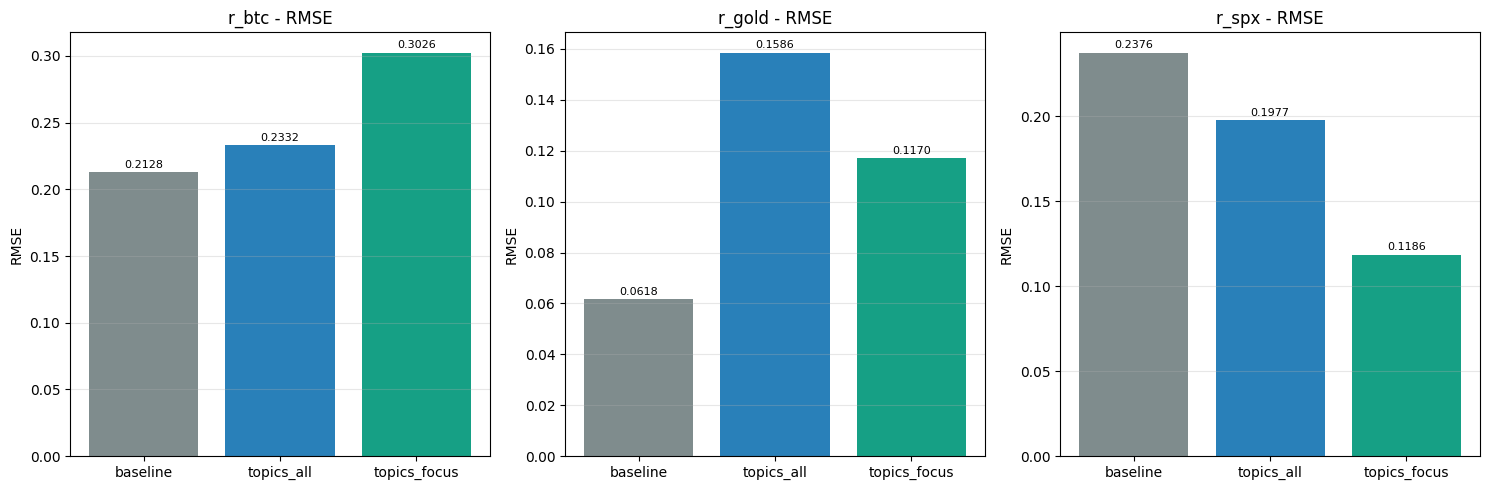

In [11]:
# Visualize RMSE vs baseline for topic models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, asset in enumerate(assets):
    ax = axes[idx]
    base_rmse = results["baseline"].get(asset, {}).get("rmse", np.nan)
    topics_all_rmse = results["topics_all"].get(asset, {}).get("rmse", np.nan)
    topics_focus_rmse = results["topics_focus"].get(asset, {}).get("rmse", np.nan)
    
    bars = ax.bar(["baseline", "topics_all", "topics_focus"],
                  [base_rmse, topics_all_rmse, topics_focus_rmse],
                  color=["#7f8c8d", "#2980b9", "#16a085"])
    ax.set_title(f"{asset} - RMSE")
    ax.set_ylabel("RMSE")
    ax.grid(True, axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.4f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.show()



## 8. Feature Importance: Topic Variables vs Controls



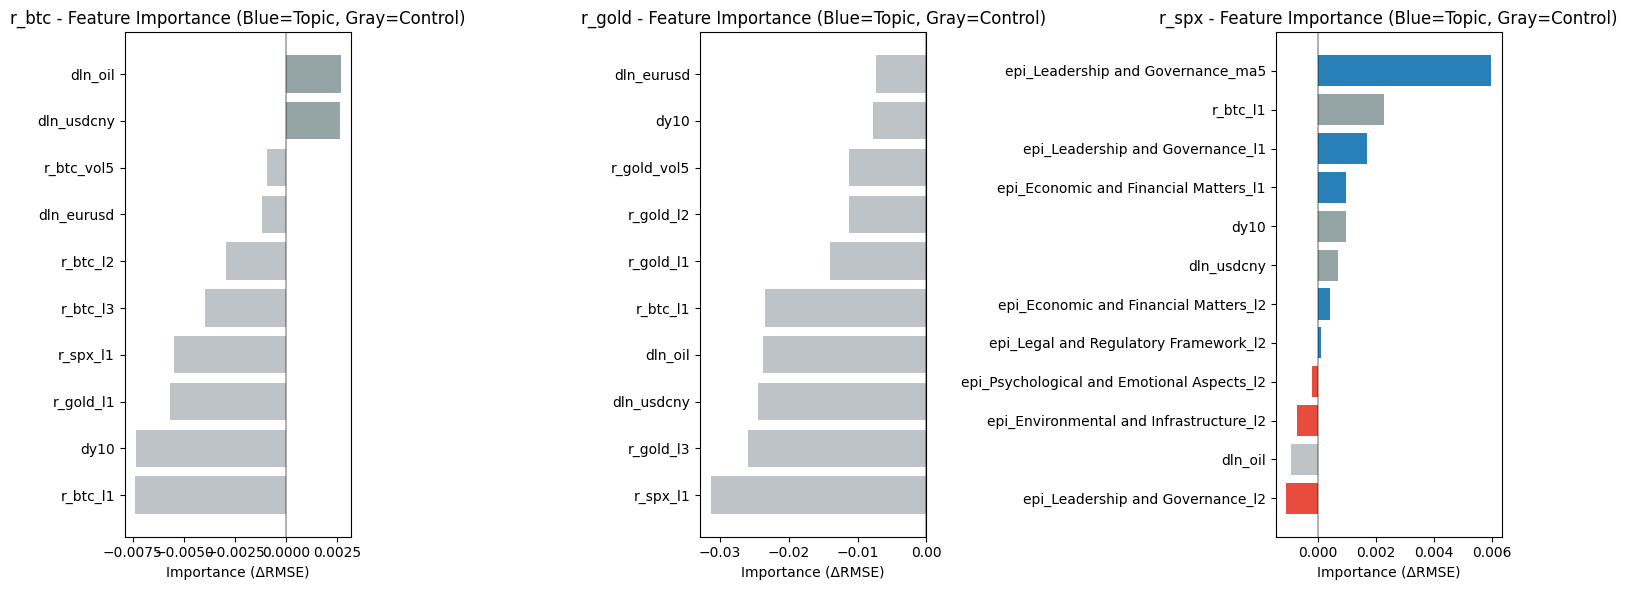

Topic importance (sum across lags/rolling):


,r_btc,r_gold,r_spx
topic,,,
epi_Economic and Financial Matters,NaN,NaN,0.0014
epi_Environmental and Infrastructure,NaN,NaN,-0.0007
epi_Leadership and Governance,NaN,NaN,0.0066
epi_Legal and Regulatory Framework,NaN,NaN,0.0001
epi_Psychological and Emotional Aspects,NaN,NaN,-0.0002


In [12]:
# Visualize feature importance - highlight topic variables
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for idx, asset in enumerate(assets):
    ax = axes[idx]
    imp_df = importance_results[asset].head(12)  # Top 12 features
    
    colors = []
    for feat in imp_df['feature']:
        if any(feat.startswith(t) for t in topic_cols_all):
            colors.append('#2980b9' if imp_df[imp_df['feature']==feat]['importance'].values[0] > 0 else '#e74c3c')
        else:
            colors.append('#95a5a6' if imp_df[imp_df['feature']==feat]['importance'].values[0] > 0 else '#bdc3c7')
    
    bars = ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
    ax.set_xlabel('Importance (ΔRMSE)')
    ax.set_title(f'{asset} - Feature Importance (Blue=Topic, Gray=Control)')
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("Topic importance (sum across lags/rolling):")
topic_table = pd.DataFrame(topic_importance_summary).drop(index='control', errors='ignore').round(4)
display(topic_table)



## Predictions vs Actuals



PREDICTIONS VS ACTUALS (Best Topic Model per Asset)


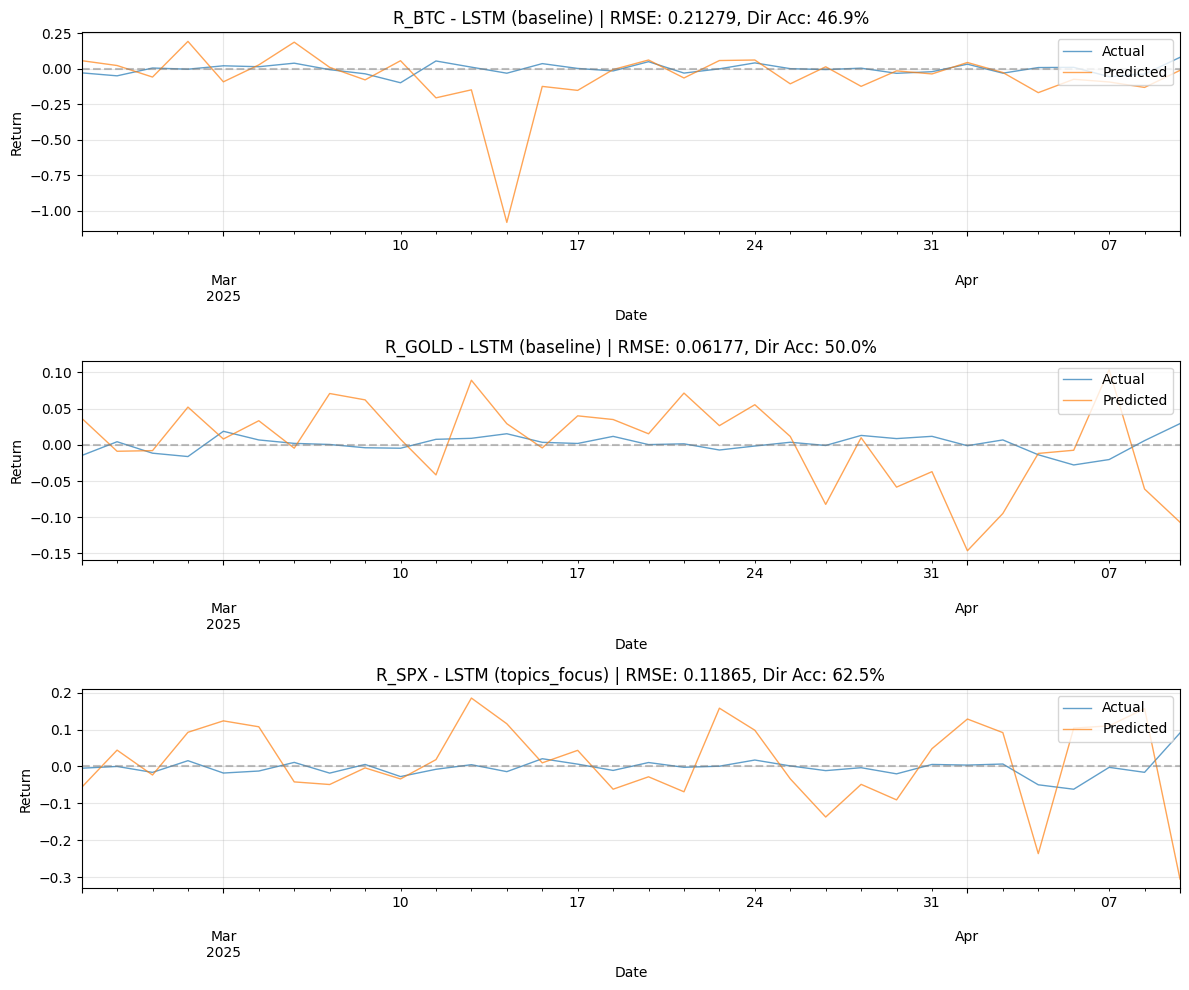

,Asset,Model,RMSE,Dir_Acc_%,N_Predictions
0,R_BTC,baseline,0.2128,46.8750,32
1,R_GOLD,baseline,0.0618,50.0000,32
2,R_SPX,topics_focus,0.1186,62.5000,32


In [13]:
# Plot predictions vs actuals using module function
from modules.finance import plot_predictions_vs_actuals

print("=" * 70)
print("PREDICTIONS VS ACTUALS (Best Topic Model per Asset)")
print("=" * 70)

fig, summary_df = plot_predictions_vs_actuals(
    results=results,
    best_models=best_models,
    assets=assets,
    title_prefix="LSTM"
)
plt.show()
display(summary_df)

## Train Final Models for Strategy Evaluation

Train the best model configuration for each asset on data **before** the test period, then predict on the test period (April-May 2025). This ensures fair out-of-sample evaluation.

In [14]:
# =============================================================================
# TRAIN FINAL MODELS AND PREDICT ON TEST PERIOD
# =============================================================================
# Train best model for each asset on data BEFORE test period
# Then predict on test period (April-May 2025) for fair comparison

print("=" * 70)
print("TRAINING FINAL MODELS FOR STRATEGY EVALUATION")
print("=" * 70)

# FIXED test period - same across ALL notebooks
TEST_START = "2025-04-01"
TEST_END = "2025-05-31"
SEQ_LEN = 8  # Must match training

# ============================================================================
# CRITICAL: Define common test dates from RAW RETURNS (before feature eng.)
# This ensures both 514 and 516 notebooks use IDENTICAL dates
# ============================================================================
COMMON_TEST_DATES = returns.loc[TEST_START:TEST_END].index
print(f"Common test dates from raw returns: {len(COMMON_TEST_DATES)} days")
print(f"  From: {COMMON_TEST_DATES.min().date()}")
print(f"  To:   {COMMON_TEST_DATES.max().date()}")

# Storage for trained models and predictions
trained_models = {}
trained_scalers = {}
test_predictions = {}

for asset in assets:
    best_model = best_models[asset]
    config = asset_configs[asset]
    
    # Get features for this asset/model (from feature selection)
    feature_cols = selected_feature_sets[best_model][asset]
    
    print(f"\n{asset.upper()} - Training {best_model} model...")
    print(f"  Features ({len(feature_cols)}): {feature_cols[:3]}...")
    
    # ========================================================================
    # TRAINING: Use feature-engineered data, drop NaN
    # ========================================================================
    df_full = data[[asset] + feature_cols].copy()
    train_df = df_full[df_full.index < TEST_START].dropna()
    
    if len(train_df) < SEQ_LEN + 10:
        print(f"  ERROR: Not enough training data ({len(train_df)} rows)")
        continue
    
    print(f"  Train: {len(train_df)} samples ({train_df.index.min().date()} to {train_df.index.max().date()})")
    
    # Scale features using training data only
    scaler = StandardScaler()
    scaler.fit(train_df[feature_cols].values)
    
    # Prepare sequences for training
    train_features = scaler.transform(train_df[feature_cols].values).astype(np.float32)
    train_target = train_df[asset].values.astype(np.float32)
    
    X_train_seq, y_train_seq, train_dates = make_sequences(
        train_features, train_target, SEQ_LEN, train_df.index
    )
    
    print(f"  Train sequences: {len(X_train_seq)}")
    
    # Build model
    model = ImprovedLSTMRegressor(
        X_train_seq.shape[-1],
        hidden_size=config['hidden_size'],
        dropout=config['dropout']
    )
    
    optimizer = AdamW(learning_rate=config['learning_rate'], weight_decay=config['weight_decay'])
    
    def loss_fn(model, xb, yb):
        return mx.mean((model(xb) - yb) ** 2)
    
    best_loss = float('inf')
    patience_counter = 0
    best_weights = None
    
    for epoch in range(config['epochs']):
        # Training step
        X_mx = mx.array(X_train_seq)
        y_mx = mx.array(y_train_seq)
        
        loss, grads = mx.value_and_grad(loss_fn)(model, X_mx, y_mx)
        optimizer.update(model, grads)
        mx.eval(model.parameters(), optimizer.state)
        
        loss_val = float(loss)
        
        # Early stopping check
        if loss_val < best_loss:
            best_loss = loss_val
            patience_counter = 0
            best_weights = copy_weights(model.parameters())
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break
    
    # Restore best weights
    if best_weights is not None:
        model.update(best_weights)
    
    # Store model and scaler
    trained_models[asset] = model
    trained_scalers[asset] = scaler
    
    # ========================================================================
    # PREDICT: Use ALL dates, fill missing values to ensure no gaps
    # Need SEQ_LEN consecutive days before each test date
    # ========================================================================
    # Get date range that covers lookback + test period
    lookback_days = pd.Timedelta(days=SEQ_LEN + 5)  # Extra buffer for weekends/holidays
    pred_start = pd.Timestamp(TEST_START) - lookback_days
    
    # Get full date range from data (not just training dates)
    pred_df = df_full.loc[pred_start:TEST_END].copy()
    pred_df = pred_df.ffill().bfill()  # Fill any gaps
    
    print(f"  Prediction window: {len(pred_df)} days ({pred_df.index.min().date()} to {pred_df.index.max().date()})")
    
    # Scale and build sequences
    pred_features = scaler.transform(pred_df[feature_cols].values).astype(np.float32)
    pred_target = pred_df[asset].values.astype(np.float32)
    
    X_test, y_test, test_dates_list = [], [], []
    for i in range(SEQ_LEN, len(pred_features)):
        date_i = pred_df.index[i]
        if date_i in COMMON_TEST_DATES:
            X_test.append(pred_features[i - SEQ_LEN : i])
            y_test.append(pred_target[i])
            test_dates_list.append(date_i)
    
    if len(X_test) > 0:
        X_test = np.array(X_test, dtype=np.float32)
        y_test = np.array(y_test, dtype=np.float32)
        
        mx.eval(model.parameters())
        preds = model(mx.array(X_test))
        preds_np = np.asarray(preds).reshape(-1)
        
        test_predictions[asset] = pd.Series(preds_np, index=pd.Index(test_dates_list))
        
        print(f"  Predictions: {len(X_test)} days ({test_dates_list[0].date()} to {test_dates_list[-1].date()})")
    else:
        print(f"  ERROR: Could not create test sequences")

print("\n" + "=" * 70)
print("MODELS TRAINED AND STORED")
print("=" * 70)

TRAINING FINAL MODELS FOR STRATEGY EVALUATION
Common test dates from raw returns: 44 days
  From: 2025-04-01
  To:   2025-05-30

R_BTC - Training baseline model...
  Features (10): ['dln_oil', 'r_btc_l1', 'r_btc_l2']...
  Train: 60 samples (2025-01-07 to 2025-03-31)
  Train sequences: 52
  Prediction window: 53 days (2025-03-19 to 2025-05-30)
  Predictions: 44 days (2025-04-01 to 2025-05-30)

R_GOLD - Training baseline model...
  Features (10): ['r_gold_l3', 'r_btc_l1', 'r_gold_l2']...
  Train: 60 samples (2025-01-07 to 2025-03-31)
  Train sequences: 52
  Prediction window: 53 days (2025-03-19 to 2025-05-30)
  Predictions: 44 days (2025-04-01 to 2025-05-30)

R_GOLD - Training baseline model...
  Features (10): ['r_gold_l3', 'r_btc_l1', 'r_gold_l2']...
  Train: 60 samples (2025-01-07 to 2025-03-31)
  Train sequences: 52
  Prediction window: 53 days (2025-03-19 to 2025-05-30)
  Predictions: 44 days (2025-04-01 to 2025-05-30)

R_SPX - Training topics_focus model...
  Features (12): ['epi_

## Cumulative Returns: Strategy vs Buy-and-Hold

Using the trained models to evaluate strategy performance on the fixed test period.

CUMULATIVE RETURNS: STRATEGY VS BUY-AND-HOLD
Test Period: 2025-04-01 to 2025-05-31


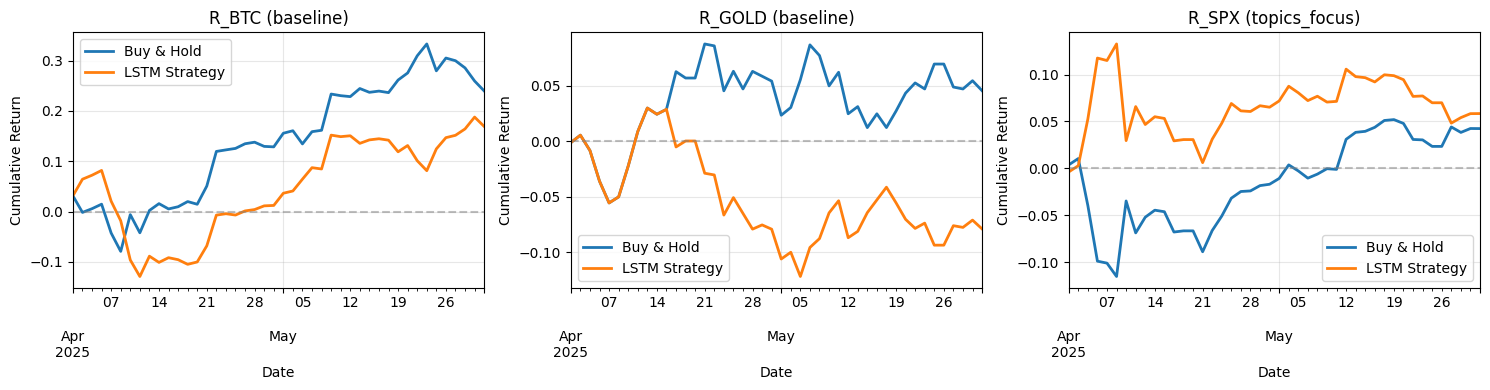


STRATEGY PERFORMANCE SUMMARY (Topic-Based LSTM)


,Asset,Model,Buy_Hold_%,Strategy_%,Outperformance_pp,N_Days,Period
0,R_BTC,baseline,23.9700,16.9100,-7.0600,44,2025-04-01 to 2025-05-30
1,R_GOLD,baseline,4.5500,-7.9000,-12.4500,44,2025-04-01 to 2025-05-30
2,R_SPX,topics_focus,4.2400,5.8400,1.6000,44,2025-04-01 to 2025-05-30



PREDICTION DATE RANGES (for cross-notebook verification)
R_BTC: 2025-04-01 to 2025-05-30 (44 days)
R_GOLD: 2025-04-01 to 2025-05-30 (44 days)
R_SPX: 2025-04-01 to 2025-05-30 (44 days)


In [15]:
# Plot cumulative returns using module function
from modules.finance import plot_cumulative_returns

print("=" * 70)
print("CUMULATIVE RETURNS: STRATEGY VS BUY-AND-HOLD")
print(f"Test Period: {TEST_START} to {TEST_END}")
print("=" * 70)

fig, strategy_df = plot_cumulative_returns(
    test_predictions=test_predictions,
    returns=returns,
    best_models=best_models,
    assets=assets,
    test_start=TEST_START,
    test_end=TEST_END,
    strategy_label="LSTM Strategy"
)
plt.show()

# Summary table
print("\n" + "=" * 70)
print("STRATEGY PERFORMANCE SUMMARY (Topic-Based LSTM)")
print("=" * 70)
display(strategy_df.round(2))

# Print exact prediction dates for cross-notebook comparison
print("\n" + "=" * 70)
print("PREDICTION DATE RANGES (for cross-notebook verification)")
print("=" * 70)
for asset in assets:
    if asset in test_predictions:
        pred = test_predictions[asset] if isinstance(test_predictions[asset], pd.Series) else test_predictions[asset]['predictions']
        print(f"{asset.upper()}: {pred.index.min().date()} to {pred.index.max().date()} ({len(pred)} days)")

## Overfitting Diagnostic

Check for overfitting by comparing **training loss vs test loss** across walk-forward folds.
- If train loss << test loss → **Overfitting**
- If train loss ≈ test loss → **Good generalization**
- If both high → **Underfitting**



OVERFITTING DIAGNOSTIC

Overfit Ratio = Test RMSE / Train RMSE
  > 2.0: OVERFITTING (model memorizes training data)
  1.5-2.0: SLIGHT OVERFIT
  0.8-1.5: GOOD generalization
  < 0.8: UNDERFITTING



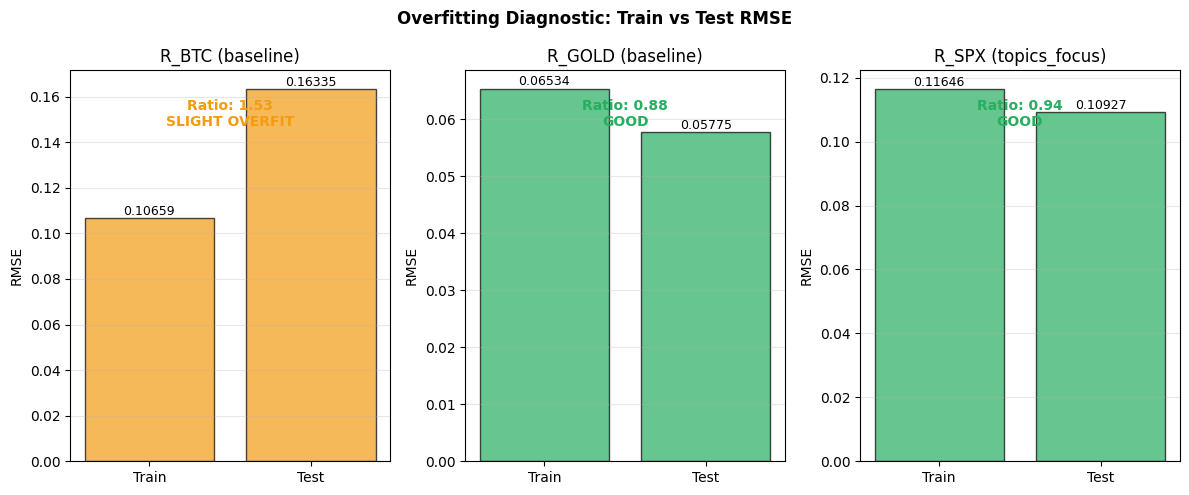


OVERFITTING SUMMARY


,Asset,Model,Train_RMSE,Test_RMSE,Ratio,Diagnosis,N_Folds
0,R_BTC,baseline,0.1066,0.1634,1.5325,SLIGHT OVERFIT,4
1,R_GOLD,baseline,0.0653,0.0578,0.8839,GOOD,4
2,R_SPX,topics_focus,0.1165,0.1093,0.9383,GOOD,4


In [16]:
# Overfitting diagnostic using module function
from modules.finance import plot_overfitting_diagnostic

print("=" * 70)
print("OVERFITTING DIAGNOSTIC")
print("=" * 70)
print("\nOverfit Ratio = Test RMSE / Train RMSE")
print("  > 2.0: OVERFITTING (model memorizes training data)")
print("  1.5-2.0: SLIGHT OVERFIT")
print("  0.8-1.5: GOOD generalization")
print("  < 0.8: UNDERFITTING")
print()

fig, overfit_df = plot_overfitting_diagnostic(
    results=results,
    best_models=best_models,
    assets=assets
)

if fig is not None:
    plt.show()

print("\n" + "=" * 70)
print("OVERFITTING SUMMARY")
print("=" * 70)
display(overfit_df.round(4))

## 9. Summary & Conclusions

### Research Question
Do topic-level EPI variables improve financial return predictions over standard control variables?

### Variables Tested
- **Variables of Interest**: Topic EPI signals (contemporaneous, lags 1-3, 5d mean) with permutation-based feature selection
- **Control Variables**: FX rates, oil prices, interest rates, lagged returns, volatility

### Key Findings
- Results above show which topic configurations improve over the baseline and which topics carry the most weight (see importance tables).
- Feature selection trims the large topic set down to the most predictive signals per asset.
- Walk-forward validation and overfitting diagnostics provide realistic out-of-sample performance checks.

